In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from datetime import datetime

from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from google.colab import drive

drive.mount('/content/drive')

train_dir = "/content/drive/MyDrive/MSc_4th_sem_Project/dataset_processed/train"
val_dir = "/content/drive/MyDrive/MSc_4th_sem_Project/dataset_processed/val"
test_dir = "/content/drive/MyDrive/MSc_4th_sem_Project/dataset_processed/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

class_names = train_ds.class_names
print("Classes:", class_names)

train_ds = train_ds.map(lambda x, y: (x / 255.0, y))
val_ds = val_ds.map(lambda x, y: (x / 255.0, y))
test_ds = test_ds.map(lambda x, y: (x / 255.0, y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

model.save("densenet121_gesture_model.h5")

Mounted at /content/drive
Found 5595 files belonging to 4 classes.
Found 1200 files belonging to 4 classes.
Found 1200 files belonging to 4 classes.
Classes: ['door_lock', 'door_unlock', 'light_off', 'light_on']
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,305,028 (27.87 MB)

 Trainable params: 265,476 (1.01 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 999s 5s/step - accuracy: 0.9206 - loss: 0.2384 - val_accuracy: 0.9858 - val_loss: 0.0898 - learning_rate: 3.0000e-04
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 26s 145ms/step - accuracy: 0.9907 - loss: 0.0405 - val_accuracy: 0.9950 - val_loss: 0.0254 - learning_rate: 3.0000e-04
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 27s 152ms/step - accuracy: 0.9962 - loss: 0.0201 - val_accuracy: 0.9950 - val_loss: 0.0169 - learning_rate: 3.0000e-04
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 41s 150ms/step - accuracy: 0.9979 - loss: 0.0123 - val_accuracy: 0.9975 - val_loss: 0.0091 - learning_rate: 3.0000e-04
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 32s 181ms/step - accuracy: 0.9986 - loss: 0.0091 - val_accuracy: 0.9975 - val_loss: 0.0075 - learning_rate: 3.0000e-04
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 26s 149ms/step - accuracy: 0.9987 - loss: 0.0075 - val_accuracy: 0.9975 - val_loss: 0.0086 - learning_rate: 3.0000e-04
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 26s 148m

Test Accuracy: 0.9991666674613953


In [ ]:
import os

MODEL_SAVE_PATH = "/content/drive/MyDrive/MSc_4th_sem_Project/models"

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
model_file = os.path.join(MODEL_SAVE_PATH, "densenet121_gesture_model.h5")

model.save(model_file)

print("Model saved at:", model_file)

✅ Model saved at: /content/drive/MyDrive/MSc_4th_sem_Project/models/densenet121_gesture_model.h5


✅ Model Loaded
Found 1200 files belonging to 4 classes.
Classes: ['door_lock', 'door_unlock', 'light_off', 'light_on']
38/38 ━━━━━━━━━━━━━━━━━━━━ 29s 432ms/step


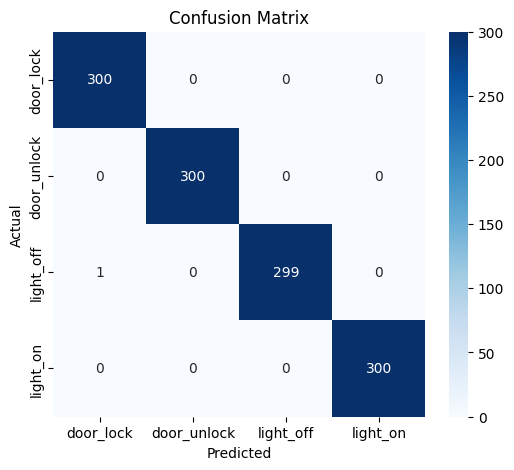


📊 Classification Report:

              precision    recall  f1-score   support

   door_lock       1.00      1.00      1.00       300
 door_unlock       1.00      1.00      1.00       300
   light_off       1.00      1.00      1.00       300
    light_on       1.00      1.00      1.00       300

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

model_path = "/content/drive/MyDrive/MSc_4th_sem_Project/models/densenet121_gesture_model.h5"
model = tf.keras.models.load_model(model_path)

print("Model Loaded")

test_dir = "/content/drive/MyDrive/MSc_4th_sem_Project/dataset_processed/test"

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

class_names = test_ds.class_names
print("Classes:", class_names)

test_ds = test_ds.map(lambda x, y: (x / 255.0, y))

y_true = np.concatenate([y for x, y in test_ds], axis=0)

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

report = classification_report(y_true, y_pred, target_names=class_names)
print("\nClassification Report:\n")
print(report)

✅ Model Loaded
📸 Upload 4 images (Ctrl + select 4)


Saving WhatsApp Image 2026-03-24 at 1.16.03 AM.jpeg to WhatsApp Image 2026-03-24 at 1.16.03 AM.jpeg
Saving WhatsApp Image 2026-03-24 at 1.20.40 AM.jpeg to WhatsApp Image 2026-03-24 at 1.20.40 AM.jpeg
Saving vtest3.jpeg to vtest3.jpeg
Saving test1.jpeg to test1.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
WhatsApp Image 2026-03-24 at 1.16.03 AM.jpeg → light_off (1.00)
WhatsApp Image 2026-03-24 at 1.20.40 AM.jpeg → door_unlock (0.99)
vtest3.jpeg → door_lock (0.95)
test1.jpeg → light_on (1.00)


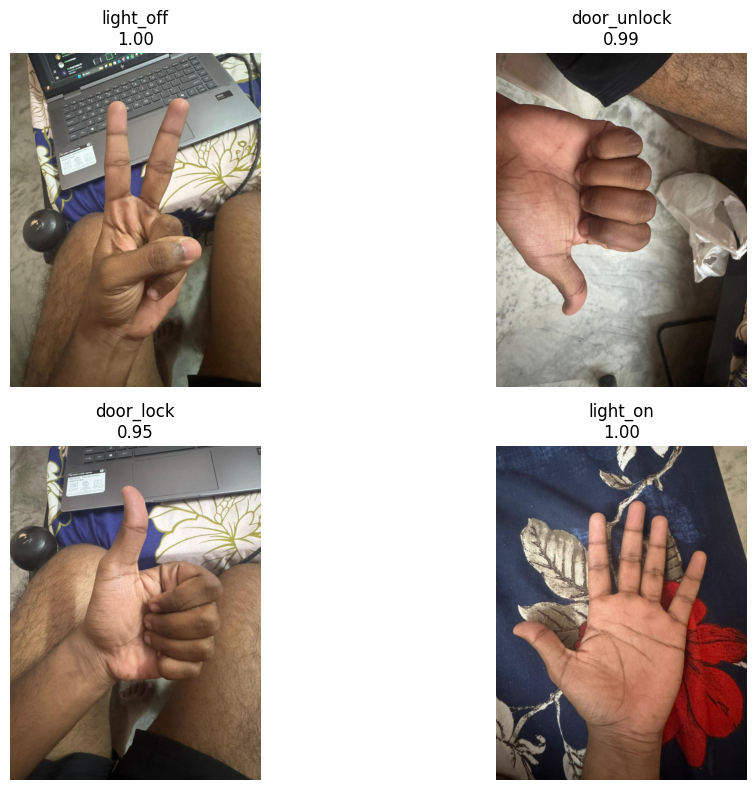

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files

model_path = "/content/drive/MyDrive/MSc_4th_sem_Project/models/densenet121_gesture_model.h5"
model = tf.keras.models.load_model(model_path)

print("Model Loaded")

class_names = ['door_lock', 'door_unlock', 'light_off', 'light_on']

print("Upload 4 images (Ctrl + select 4)")
uploaded = files.upload()

images = []
img_names = []

for img_name in uploaded.keys():
    img = image.load_img(img_name, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    images.append(img_array)
    img_names.append(img_name)

images = np.array(images)

preds = model.predict(images)

plt.figure(figsize=(12, 8))

for i in range(len(images)):
    pred_class = class_names[np.argmax(preds[i])]
    confidence = np.max(preds[i])

    plt.subplot(2, 2, i + 1)
    img = image.load_img(img_names[i])
    plt.imshow(img)
    plt.title(f"{pred_class}\n{confidence:.2f}")
    plt.axis('off')

    print(f"{img_names[i]} → {pred_class} ({confidence:.2f})")

plt.tight_layout()
plt.show()

✅ Model Loaded
📸 Upload 4 images (Ctrl + select 4)


Saving ntest1.jpeg to ntest1.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
ntest1.jpeg → door_unlock (0.98)


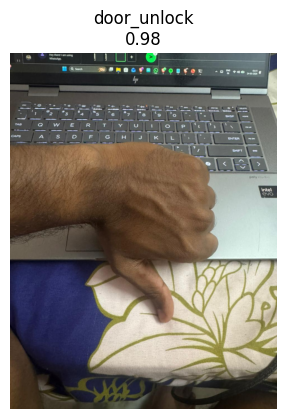

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files

model_path = "/content/drive/MyDrive/MSc_4th_sem_Project/models/densenet121_gesture_model.h5"
model = tf.keras.models.load_model(model_path)

print("Model Loaded")

class_names = ['door_lock', 'door_unlock', 'light_off', 'light_on']

print("Upload 4 images (Ctrl + select 4)")
uploaded = files.upload()

images = []
img_names = []

for img_name in uploaded.keys():
    img = image.load_img(img_name, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0

    images.append(img_array)
    img_names.append(img_name)

images = np.array(images)

preds = model.predict(images)

plt.figure(figsize=(12, 8))

for i in range(len(images)):
    pred_class = class_names[np.argmax(preds[i])]
    confidence = np.max(preds[i])

    plt.subplot(2, 2, i + 1)
    img = image.load_img(img_names[i])
    plt.imshow(img)
    plt.title(f"{pred_class}\n{confidence:.2f}")
    plt.axis('off')

    print(f"{img_names[i]} → {pred_class} ({confidence:.2f})")

plt.tight_layout()
plt.show()

✅ Model Loaded
📸 Upload 4 images (Ctrl + select 4)


Saving WhatsApp Image 2026-03-24 at 1.20.40 AM.jpeg to WhatsApp Image 2026-03-24 at 1.20.40 AM (2).jpeg
Saving vtest3.jpeg to vtest3 (2).jpeg
Saving ntest1.jpeg to ntest1 (2).jpeg
Saving test4.jpeg to test4.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
WhatsApp Image 2026-03-24 at 1.20.40 AM (2).jpeg → door_unlock (0.99)
vtest3 (2).jpeg → door_lock (0.95)
ntest1 (2).jpeg → door_unlock (0.98)
test4.jpeg → door_lock (0.99)


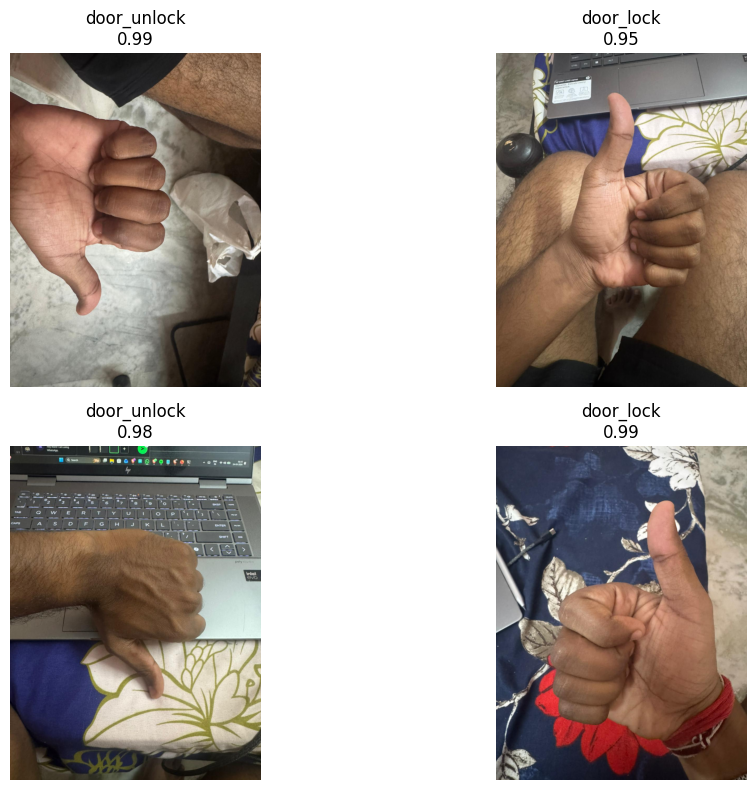

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files

model_path = "/content/drive/MyDrive/MSc_4th_sem_Project/models/finaldensesnet_model.keras"
model = tf.keras.models.load_model(model_path)

print("Model Loaded")

class_names = ['door_lock', 'door_unlock', 'light_off', 'light_on']

print("Upload 4 images (Ctrl + select 4)")
uploaded = files.upload()

images = []
img_names = []

for img_name in uploaded.keys():
    img = image.load_img(img_name, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0

    images.append(img_array)
    img_names.append(img_name)

images = np.array(images)

preds = model.predict(images)

plt.figure(figsize=(12, 8))

for i in range(len(images)):
    pred_class = class_names[np.argmax(preds[i])]
    confidence = np.max(preds[i])

    plt.subplot(2, 2, i + 1)
    img = image.load_img(img_names[i])
    plt.imshow(img)
    plt.title(f"{pred_class}\n{confidence:.2f}")
    plt.axis('off')

    print(f"{img_names[i]} → {pred_class} ({confidence:.2f})")

plt.tight_layout()
plt.show()